# Estimate the Methodology-Only Impact of Announced PCE Deflator Changes on Core PCE

This notebook estimates a methodology-only counterfactual for core PCE inflation using current-vintage nominal PCE and current-vintage PCE price indexes. It holds nominal spending and all unaffected component deflators fixed, then replaces only the affected component deflators with proxy "new-methodology" deflators.

Components included:

- Portfolio management and investment advice services
- Legal services
- Computer software and accessories

Professional association dues are intentionally excluded.

The output is not a forecast of the full BEA annual update. It is an auditable approximation of the direct deflator-methodology effect on core PCE inflation.

## 2. Imports and Settings

In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt


pd.options.display.max_columns = 120
pd.options.display.max_rows = 200
pd.options.display.float_format = "{:,.6f}".format

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 3. User Parameters

In [3]:
# Edit these parameters and then run the notebook from top to bottom.

START_DATE = "2021-01-01"
END_DATE = None  # None means use latest common month

# The notebook will try to read API Keys.txt with lines like "BEA: key".
# You can also paste keys directly below.
KEY_FILE = Path("API Keys.txt")


def load_api_keys(path=KEY_FILE):
    keys = {}
    if Path(path).exists():
        for line in Path(path).read_text(encoding="utf-8").splitlines():
            if ":" in line:
                name, value = line.split(":", 1)
                keys[name.strip().upper()] = value.strip()
    return keys


_API_KEYS = load_api_keys(KEY_FILE)

BEA_API_KEY = _API_KEYS.get("BEA", "PUT_BEA_KEY_HERE")
BLS_API_KEY = _API_KEYS.get("BLS") or None  # optional

SOFTWARE_APPLY_FROM = "2021-01-01"
PORTFOLIO_APPLY_FROM = "2021-01-01"
LEGAL_APPLY_FROM = "2024-01-01"

SOFTWARE_WEIGHTS = {
    "cpi_software_accessories": 0.10,
    "ppi_game_software_publishing": 0.45,
    "ppi_hosting_asp_it_infrastructure": 0.45,
}

# BLS CPI software has a missing October 2025 observation due to the 2025 lapse in appropriations.
# When enabled, the notebook imputes only the listed missing index levels as sqrt(previous * next).
IMPUTE_CPI_SOFTWARE_GEOMEAN_GAPS = True
CPI_SOFTWARE_GEOMEAN_IMPUTE_DATES = ["2025-10-01"]

# Optional bridge for latest-month estimates when the CES portfolio quantity proxy lags PCE data.
# This is a nowcast assumption, not source data. Set to [] to keep the strict common-sample rule.
PORTFOLIO_QUANTITY_FLAT_NOWCAST_DATES = ["2026-05-01"]

SAVE_OUTPUTS = True
OUTPUT_DIR = "outputs"


START_DATE = pd.Timestamp(START_DATE).to_period("M").to_timestamp()
END_DATE = None if END_DATE is None else pd.Timestamp(END_DATE).to_period("M").to_timestamp()
SOFTWARE_APPLY_FROM = pd.Timestamp(SOFTWARE_APPLY_FROM).to_period("M").to_timestamp()
PORTFOLIO_APPLY_FROM = pd.Timestamp(PORTFOLIO_APPLY_FROM).to_period("M").to_timestamp()
LEGAL_APPLY_FROM = pd.Timestamp(LEGAL_APPLY_FROM).to_period("M").to_timestamp()
CPI_SOFTWARE_GEOMEAN_IMPUTE_DATES = [pd.Timestamp(x).to_period("M").to_timestamp() for x in CPI_SOFTWARE_GEOMEAN_IMPUTE_DATES]
PORTFOLIO_QUANTITY_FLAT_NOWCAST_DATES = [pd.Timestamp(x).to_period("M").to_timestamp() for x in PORTFOLIO_QUANTITY_FLAT_NOWCAST_DATES]

APPLY_DATES = {
    "Computer software and accessories": SOFTWARE_APPLY_FROM,
    "Portfolio management and investment advice services": PORTFOLIO_APPLY_FROM,
    "Legal services": LEGAL_APPLY_FROM,
}

weight_sum = sum(SOFTWARE_WEIGHTS.values())
assert np.isclose(weight_sum, 1.0), f"Software weights must sum to 1.0; got {weight_sum:.8f}"

# Fetch one extra year because log changes, splice anchors, and 12-month rates need history.
fetch_start_date = min([START_DATE, SOFTWARE_APPLY_FROM, PORTFOLIO_APPLY_FROM, LEGAL_APPLY_FROM]) - pd.DateOffset(months=13)
fetch_end_date = END_DATE

print("Methodology-only estimate, holding nominal PCE and all unaffected deflators fixed")
print("Start date:", START_DATE.date())
print("End date:", "latest common month" if END_DATE is None else END_DATE.date())
print("Apply dates:", {k: v.date().isoformat() for k, v in APPLY_DATES.items()})
print("Software weights:", SOFTWARE_WEIGHTS)
print("CPI software geometric-mean imputations:", [x.date().isoformat() for x in CPI_SOFTWARE_GEOMEAN_IMPUTE_DATES] if IMPUTE_CPI_SOFTWARE_GEOMEAN_GAPS else "disabled")
print("Portfolio quantity flat nowcast dates:", [x.date().isoformat() for x in PORTFOLIO_QUANTITY_FLAT_NOWCAST_DATES] if PORTFOLIO_QUANTITY_FLAT_NOWCAST_DATES else "disabled")
print("BEA key source:", "API Keys.txt" if _API_KEYS.get("BEA") else "manual parameter cell")
print("BLS key supplied:", BLS_API_KEY is not None)

Methodology-only estimate, holding nominal PCE and all unaffected deflators fixed
Start date: 2021-01-01
End date: latest common month
Apply dates: {'Computer software and accessories': '2021-01-01', 'Portfolio management and investment advice services': '2021-01-01', 'Legal services': '2024-01-01'}
Software weights: {'cpi_software_accessories': 0.1, 'ppi_game_software_publishing': 0.45, 'ppi_hosting_asp_it_infrastructure': 0.45}
CPI software geometric-mean imputations: ['2025-10-01']
Portfolio quantity flat nowcast dates: ['2026-05-01']
BEA key source: API Keys.txt
BLS key supplied: True


## 4. Data-Fetching Functions

In [4]:
BEA_BASE_URL = "https://apps.bea.gov/api/data/"
BLS_BASE_URL = "https://api.bls.gov/publicAPI/v2/timeseries/data/"
FRED_CSV_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv"


FRED_SERIES = {
    "core_pce_price_index": "PCEPILFE",
    "nominal_core_pce": "DPCCRC1M027SBEA",
    "ppi_legal_services": "PCU541110541110",
    "ppi_portfolio_management": "PCU523940523940",
    "ppi_game_software_publishing": "PCU5112105112107",
    "ppi_hosting_asp_it_infrastructure": "PCU5182105182105",
}

BLS_CPI_SOFTWARE_CANDIDATES = ["CUSR0000SEEE02", "CUUR0000SEEE02"]
BLS_PORTFOLIO_SERIES = {
    "portfolio_emp_523940": "CES5552394001",
    "portfolio_hours_523940": "CES5552394002",
    "fallback_emp_523920": "CES5552392001",
    "fallback_emp_523930": "CES5552393001",
}

COMPONENT_SEARCH = {
    "Portfolio management and investment advice services": {
        "search_terms": ["portfolio", "management", "investment", "advice"],
        "exact_phrase": "portfolio management and investment advice services",
        "exclude_terms": ["professional association dues"],
    },
    "Legal services": {
        "search_terms": ["legal", "services"],
        "exact_phrase": "legal services",
        "exclude_terms": ["professional association dues"],
    },
    "Computer software and accessories": {
        "search_terms": ["computer", "software", "accessories"],
        "exact_phrase": "computer software and accessories",
        "exclude_terms": ["professional association dues"],
    },
}


def month_start(x):
    return pd.Timestamp(x).to_period("M").to_timestamp()


def clean_bea_value(x):
    if pd.isna(x):
        return np.nan
    text = str(x).strip()
    if text in {"", "(NA)", "NA", "..."}:
        return np.nan
    return pd.to_numeric(text.replace(",", ""), errors="coerce")


def parse_bea_time_period(x):
    text = str(x).strip()
    if "M" in text:
        year, month = text.split("M", 1)
        return pd.Timestamp(int(year), int(month), 1)
    if "Q" in text:
        year, quarter = text.split("Q", 1)
        month = 3 * int(quarter) - 2
        return pd.Timestamp(int(year), month, 1)
    if len(text) == 4 and text.isdigit():
        return pd.Timestamp(int(text), 1, 1)
    return pd.NaT


def coerce_monthly_series(df, date_col, value_col, name):
    out = df[[date_col, value_col]].copy()
    out[date_col] = pd.to_datetime(out[date_col]).dt.to_period("M").dt.to_timestamp()
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = (
        out.dropna(subset=[date_col])
        .drop_duplicates(subset=[date_col], keep="last")
        .sort_values(date_col)
        .set_index(date_col)[value_col]
        .rename(name)
    )
    return out


def impute_index_geomean_gaps(series, impute_dates, label):
    """Fill explicitly listed missing index levels as sqrt(previous valid month * next valid month)."""
    out = series.astype(float).sort_index().copy()
    records = []
    for dt in impute_dates:
        dt = month_start(dt)
        prev_dt = dt - pd.DateOffset(months=1)
        next_dt = dt + pd.DateOffset(months=1)
        existing = out.get(dt, np.nan)
        prev_value = out.get(prev_dt, np.nan)
        next_value = out.get(next_dt, np.nan)
        if pd.notna(existing):
            records.append({"series": label, "date": dt, "status": "not imputed; existing value present", "imputed_value": existing})
            continue
        if pd.isna(prev_value) or pd.isna(next_value):
            raise ValueError(
                f"{label}: cannot geometrically impute {dt.date()} because "
                f"adjacent values are missing: previous={prev_value}, next={next_value}."
            )
        imputed_value = float(np.sqrt(prev_value * next_value))
        out.loc[dt] = imputed_value
        records.append(
            {
                "series": label,
                "date": dt,
                "status": "imputed as sqrt(previous * next)",
                "previous_month": prev_dt,
                "previous_value": prev_value,
                "next_month": next_dt,
                "next_value": next_value,
                "imputed_value": imputed_value,
            }
        )
    return out.sort_index().rename(series.name), pd.DataFrame(records)


def nowcast_series_flat_dates(series, nowcast_dates, label):
    """Fill explicitly listed latest-month nowcast levels with the previous month's value."""
    out = series.astype(float).sort_index().copy()
    records = []
    for dt in nowcast_dates:
        dt = month_start(dt)
        prev_dt = dt - pd.DateOffset(months=1)
        existing = out.get(dt, np.nan)
        prev_value = out.get(prev_dt, np.nan)
        if pd.notna(existing):
            records.append({"series": label, "date": dt, "status": "not nowcast; existing value present", "nowcast_value": existing})
            continue
        if pd.isna(prev_value):
            raise ValueError(f"{label}: cannot flat-nowcast {dt.date()} because {prev_dt.date()} is missing.")
        out.loc[dt] = float(prev_value)
        records.append(
            {
                "series": label,
                "date": dt,
                "status": "nowcast as previous month's value",
                "previous_month": prev_dt,
                "previous_value": prev_value,
                "nowcast_value": float(prev_value),
            }
        )
    return out.sort_index().rename(series.name), pd.DataFrame(records)


def fetch_fred_csv(series_id):
    response = requests.get(FRED_CSV_URL, params={"id": series_id}, timeout=60)
    response.raise_for_status()
    from io import StringIO

    df = pd.read_csv(StringIO(response.text))
    if series_id not in df.columns:
        raise ValueError(f"FRED response for {series_id} did not include the requested column.")
    df[series_id] = pd.to_numeric(df[series_id].replace(".", np.nan), errors="coerce")
    series = coerce_monthly_series(df, "observation_date", series_id, series_id)
    return series


def fetch_bls_series(series_ids, start_year, end_year, api_key=None):
    series_ids = list(dict.fromkeys(series_ids))
    payload = {
        "seriesid": series_ids,
        "startyear": str(start_year),
        "endyear": str(end_year),
    }
    if api_key:
        payload["registrationkey"] = api_key

    response = requests.post(BLS_BASE_URL, json=payload, timeout=60)
    response.raise_for_status()
    data = response.json()

    if data.get("status") != "REQUEST_SUCCEEDED":
        raise ValueError(f"BLS request failed: {data.get('message', data)}")

    output = {}
    for item in data.get("Results", {}).get("series", []):
        sid = item.get("seriesID")
        rows = []
        for obs in item.get("data", []):
            period = obs.get("period", "")
            if not period.startswith("M") or period == "M13":
                continue
            rows.append(
                {
                    "date": pd.Timestamp(int(obs["year"]), int(period[1:]), 1),
                    "value": pd.to_numeric(obs.get("value"), errors="coerce"),
                }
            )
        if rows:
            output[sid] = coerce_monthly_series(pd.DataFrame(rows), "date", "value", sid)
        else:
            output[sid] = pd.Series(dtype=float, name=sid)
    for sid in series_ids:
        output.setdefault(sid, pd.Series(dtype=float, name=sid))
    return output


def fetch_bea_table(table_name, api_key):
    if not api_key or "PUT_BEA_KEY_HERE" in str(api_key):
        raise ValueError("Enter a BEA API key in the parameter cell or provide API Keys.txt.")

    errors = []
    for year_arg in ["X", "ALL"]:
        params = {
            "UserID": api_key,
            "method": "GetData",
            "DatasetName": "NIUnderlyingDetail",
            "TableName": table_name,
            "Frequency": "M",
            "Year": year_arg,
            "ResultFormat": "JSON",
        }
        try:
            response = requests.get(BEA_BASE_URL, params=params, timeout=90)
            response.raise_for_status()
            payload = response.json()
            bea = payload.get("BEAAPI", {})
            if bea.get("Error"):
                errors.append(f"Year={year_arg}: {bea['Error']}")
                continue
            data = bea.get("Results", {}).get("Data")
            if data is None:
                errors.append(f"Year={year_arg}: no Results.Data in response")
                continue
            if isinstance(data, dict):
                data = [data]
            df = pd.DataFrame(data)
            if df.empty:
                errors.append(f"Year={year_arg}: empty table")
                continue
            df["date"] = df["TimePeriod"].map(parse_bea_time_period)
            df["value"] = df["DataValue"].map(clean_bea_value)
            sort_cols = [col for col in ["LineNumber", "date"] if col in df.columns]
            df = df.dropna(subset=["date"]).sort_values(sort_cols, kind="stable")
            df["source_table"] = table_name
            return df
        except Exception as exc:
            errors.append(f"Year={year_arg}: {exc}")

    raise RuntimeError(f"Could not retrieve BEA table {table_name}. Attempts: {errors}")


def normalize_text(x):
    return " ".join(str(x).lower().replace("&", "and").split())


def find_bea_row(df, search_terms, table_name, exact_phrase=None, exclude_terms=None):
    exclude_terms = exclude_terms or []
    cols = [
        col
        for col in ["LineNumber", "LineDescription", "SeriesCode", "METRIC_NAME", "CL_UNIT", "UNIT_MULT"]
        if col in df.columns
    ]
    catalog = df[cols].drop_duplicates().copy()
    catalog["match_text"] = (
        catalog.get("LineDescription", "").astype(str)
        + " "
        + catalog.get("SeriesCode", "").astype(str)
    ).map(normalize_text)

    term_mask = pd.Series(True, index=catalog.index)
    for term in search_terms:
        term_mask &= catalog["match_text"].str.contains(normalize_text(term), regex=False, na=False)

    if exact_phrase:
        phrase = normalize_text(exact_phrase)
        exact_mask = catalog.get("LineDescription", "").astype(str).map(normalize_text).str.contains(
            phrase, regex=False, na=False
        )
        mask = exact_mask if exact_mask.any() else term_mask
    else:
        mask = term_mask

    for term in exclude_terms:
        mask &= ~catalog["match_text"].str.contains(normalize_text(term), regex=False, na=False)

    matches = catalog.loc[mask].drop(columns=["match_text"])
    display(matches)
    if len(matches) != 1:
        raise ValueError(
            f"BEA row matcher found {len(matches)} rows in {table_name}. "
            "Review the candidates printed above and edit COMPONENT_SEARCH or the matching logic."
        )
    return matches.iloc[0]


def extract_bea_series(df, matched_row, name):
    mask = pd.Series(True, index=df.index)

    if "SeriesCode" in df.columns and pd.notna(matched_row.get("SeriesCode")) and str(matched_row.get("SeriesCode")):
        mask &= df["SeriesCode"].astype(str) == str(matched_row["SeriesCode"])
    else:
        if "LineNumber" in df.columns and pd.notna(matched_row.get("LineNumber")):
            mask &= df["LineNumber"].astype(str) == str(matched_row["LineNumber"])
        if "LineDescription" in df.columns and pd.notna(matched_row.get("LineDescription")):
            mask &= df["LineDescription"].astype(str) == str(matched_row["LineDescription"])

    out = (
        df.loc[mask, ["date", "value"]]
        .dropna(subset=["date"])
        .drop_duplicates(subset=["date"], keep="last")
        .sort_values("date")
        .set_index("date")["value"]
        .rename(name)
    )
    return out


def dlog(series):
    series = series.astype(float).sort_index()
    return np.log(series / series.shift(1))


def chain_from_dlog(dlog_series, anchor_date, anchor_value):
    anchor_date = month_start(anchor_date)
    index = pd.DatetimeIndex(dlog_series.index.union(pd.DatetimeIndex([anchor_date]))).sort_values()
    out = pd.Series(index=index, dtype=float, name="chained_index")
    out.loc[anchor_date] = float(anchor_value)

    prev_date = anchor_date
    for dt in index[index > anchor_date]:
        step = dlog_series.get(dt, np.nan)
        if pd.isna(step) or pd.isna(out.loc[prev_date]):
            out.loc[dt] = np.nan
        else:
            out.loc[dt] = out.loc[prev_date] * np.exp(step)
        prev_date = dt
    return out


def splice_proxy_index(old_index, proxy_dlog, apply_from, name):
    apply_from = month_start(apply_from)
    anchor_date = apply_from - pd.DateOffset(months=1)
    old_index = old_index.astype(float).sort_index()
    proxy_dlog = proxy_dlog.astype(float).sort_index()

    if anchor_date not in old_index.index or pd.isna(old_index.loc[anchor_date]):
        raise ValueError(f"{name}: old BEA index is missing the splice anchor {anchor_date.date()}.")

    chained = chain_from_dlog(proxy_dlog, anchor_date, old_index.loc[anchor_date])
    new_index = old_index.copy().rename(f"{name}_new_index")

    replacement_dates = new_index.index[new_index.index >= apply_from]
    new_index.loc[replacement_dates] = chained.reindex(replacement_dates)
    check_splice_continuity(old_index, new_index, apply_from, name)
    return new_index


def check_splice_continuity(old_index, new_index, apply_from, name, tol=1e-8):
    anchor_date = month_start(apply_from) - pd.DateOffset(months=1)
    if anchor_date not in old_index.index or anchor_date not in new_index.index:
        raise ValueError(f"{name}: cannot test splice continuity at {anchor_date.date()}.")
    diff = abs(float(old_index.loc[anchor_date]) - float(new_index.loc[anchor_date]))
    assert diff <= tol, f"{name}: replacement index is not continuous at the splice anchor."


def make_diagnostics_table(series_dict, start_date=None, end_date=None):
    rows = []
    for name, series in series_dict.items():
        s = series.dropna().sort_index()
        if len(s) == 0:
            rows.append(
                {
                    "series": name,
                    "first_valid_date": pd.NaT,
                    "last_valid_date": pd.NaT,
                    "observations": 0,
                    "missing_observations_in_window": np.nan,
                }
            )
            continue
        first = s.index.min()
        last = s.index.max()
        window_start = month_start(start_date) if start_date is not None else first
        window_end = month_start(end_date) if end_date is not None else last
        window_start = max(window_start, first)
        window_end = min(window_end, last)
        if window_start <= window_end:
            monthly_index = pd.date_range(window_start, window_end, freq="MS")
            missing = int(series.reindex(monthly_index).isna().sum())
        else:
            missing = np.nan
        rows.append(
            {
                "series": name,
                "first_valid_date": first,
                "last_valid_date": last,
                "observations": int(s.shape[0]),
                "missing_observations_in_window": missing,
            }
        )
    return pd.DataFrame(rows).sort_values("series").reset_index(drop=True)


def latest_common_contiguous_index(required_frame, start_date):
    valid = required_frame.dropna(how="any").sort_index()
    if valid.empty:
        raise ValueError("No common valid dates across required inputs.")
    start_date = month_start(start_date)
    candidate_start = max(start_date, valid.index.min())
    expected = pd.date_range(candidate_start, valid.index.max(), freq="MS")
    keep = []
    valid_set = set(valid.index)
    for dt in expected:
        if dt in valid_set:
            keep.append(dt)
        else:
            break
    if not keep:
        raise ValueError("No contiguous monthly sample starts at the requested start date.")
    return pd.DatetimeIndex(keep)

## 5. BEA Data Retrieval

In [5]:
# BEA detailed monthly PCE tables:
# U20404 = Table 2.4.4U, PCE price indexes
# U20405 = Table 2.4.5U, current-dollar PCE

bea_price = fetch_bea_table("U20404", BEA_API_KEY)
bea_nominal = fetch_bea_table("U20405", BEA_API_KEY)

print("BEA price rows:", bea_price.shape)
print("BEA nominal rows:", bea_nominal.shape)
print("BEA price date range:", bea_price["date"].min().date(), "to", bea_price["date"].max().date())
print("BEA nominal date range:", bea_nominal["date"].min().date(), "to", bea_nominal["date"].max().date())

BEA price rows: (302614, 13)
BEA nominal rows: (304232, 13)
BEA price date range: 1959-01-01 to 2026-05-01
BEA nominal date range: 1959-01-01 to 2026-05-01


## 6. FRED/BLS Data Retrieval

In [6]:
# FRED CSV downloads do not require a FRED API key.
fred = {}
for label, series_id in FRED_SERIES.items():
    print(f"Fetching FRED {label}: {series_id}")
    fred[label] = fetch_fred_csv(series_id)

bls_start_year = int(fetch_start_date.year)
bls_end_year = int((END_DATE if END_DATE is not None else pd.Timestamp.today()).year)

# Try seasonally adjusted CPI software first. If it is unavailable, use not-seasonally-adjusted CPI.
print("Fetching BLS CPI software candidates:", BLS_CPI_SOFTWARE_CANDIDATES)
bls_cpi_candidates = fetch_bls_series(BLS_CPI_SOFTWARE_CANDIDATES, bls_start_year, bls_end_year, BLS_API_KEY)

cpi_software_series_id = None
for candidate in BLS_CPI_SOFTWARE_CANDIDATES:
    s = bls_cpi_candidates[candidate].dropna()
    if not s.empty:
        cpi_software_series_id = candidate
        break
if cpi_software_series_id is None:
    raise ValueError("Neither CPI software candidate returned valid observations.")

cpi_software_is_sa = cpi_software_series_id.startswith("CUSR")
if not cpi_software_is_sa:
    warnings.warn(
        "Using CUUR0000SEEE02, the not-seasonally-adjusted CPI computer software and accessories series. "
        "Month-over-month annualized impacts may be affected by seasonal-adjustment mismatch."
    )

bls_cpi_software = bls_cpi_candidates[cpi_software_series_id].rename("cpi_software_accessories")
cpi_software_imputations = pd.DataFrame()
if IMPUTE_CPI_SOFTWARE_GEOMEAN_GAPS:
    bls_cpi_software, cpi_software_imputations = impute_index_geomean_gaps(
        bls_cpi_software,
        CPI_SOFTWARE_GEOMEAN_IMPUTE_DATES,
        f"BLS CPI software ({cpi_software_series_id})",
    )
    if not cpi_software_imputations.empty:
        print("CPI software index imputations:")
        display(cpi_software_imputations)

print("Selected CPI software series:", cpi_software_series_id, "(seasonally adjusted:", cpi_software_is_sa, ")")

print("Fetching BLS CES portfolio quantity candidates")
bls_portfolio_raw = fetch_bls_series(
    list(BLS_PORTFOLIO_SERIES.values()), bls_start_year, bls_end_year, BLS_API_KEY
)
bls_portfolio = {label: bls_portfolio_raw[sid].rename(label) for label, sid in BLS_PORTFOLIO_SERIES.items()}

Fetching FRED core_pce_price_index: PCEPILFE
Fetching FRED nominal_core_pce: DPCCRC1M027SBEA
Fetching FRED ppi_legal_services: PCU541110541110
Fetching FRED ppi_portfolio_management: PCU523940523940
Fetching FRED ppi_game_software_publishing: PCU5112105112107
Fetching FRED ppi_hosting_asp_it_infrastructure: PCU5182105182105
Fetching BLS CPI software candidates: ['CUSR0000SEEE02', 'CUUR0000SEEE02']
CPI software index imputations:


C:\Users\abour\AppData\Local\Temp\ipykernel_4932\2242893143.py:25: UserWarning: Using CUUR0000SEEE02, the not-seasonally-adjusted CPI computer software and accessories series. Month-over-month annualized impacts may be affected by seasonal-adjustment mismatch.
  warnings.warn(


,series,date,status,previous_month,previous_value,next_month,next_value,imputed_value
0,BLS CPI software (CUUR0000SEEE02),2025-10-01,imputed as sqrt(previous * next),2025-09-01,21.991000,2025-11-01,22.182000,22.086294


Selected CPI software series: CUUR0000SEEE02 (seasonally adjusted: False )
Fetching BLS CES portfolio quantity candidates


## 6a. Optional Seasonal-Adjustment Hooks

This section is intentionally placed after source retrieval and before proxy construction. Edit the function below if you want to replace any non-seasonally adjusted CPI/PPI input with your own adjusted version. By default it returns the source series unchanged, so the notebook remains fully reproducible without requiring X-13 or another seasonal-adjustment dependency.

In [7]:
def adjust_nonseasonally_adjusted_series(series, series_name):
    """Placeholder for user-supplied seasonal adjustment of an index-level series.

    Parameters
    ----------
    series : pandas.Series
        Monthly index levels for a source series that may not be seasonally adjusted.
    series_name : str
        Friendly source name, useful if you want series-specific adjustment logic.

    Returns
    -------
    pandas.Series
        Monthly index levels on the same date index. The default no-op behavior returns
        a copy of the input series unchanged.
    """
    # Replace this body with your preferred seasonal-adjustment method or with a
    # pre-adjusted series loaded from another source. Keep the output as index levels,
    # not log changes, because downstream cells compute log changes consistently.
    return series.copy()


def adjust_nonseasonally_adjusted_sources(source_series):
    """Apply the placeholder adjustment function to each NSA proxy-source candidate."""
    adjusted = {}
    records = []
    for name, series in source_series.items():
        original = series.astype(float).sort_index()
        adjusted_series = adjust_nonseasonally_adjusted_series(original, name).astype(float).sort_index()
        adjusted_series = adjusted_series.rename(original.name)
        adjusted[name] = adjusted_series

        common = original.dropna().index.intersection(adjusted_series.dropna().index)
        max_abs_level_change = np.nan
        if len(common) > 0:
            max_abs_level_change = float((adjusted_series.loc[common] - original.loc[common]).abs().max())
        records.append(
            {
                "series": name,
                "first_valid_date": adjusted_series.dropna().index.min() if not adjusted_series.dropna().empty else pd.NaT,
                "last_valid_date": adjusted_series.dropna().index.max() if not adjusted_series.dropna().empty else pd.NaT,
                "observations": int(adjusted_series.dropna().shape[0]),
                "max_abs_level_change_vs_raw": max_abs_level_change,
                "status": "no-op unless you edit adjust_nonseasonally_adjusted_series",
            }
        )
    return adjusted, pd.DataFrame(records)


nonseasonally_adjusted_proxy_sources = {
    "cpi_software_accessories": bls_cpi_software,
    "ppi_game_software_publishing": fred["ppi_game_software_publishing"],
    "ppi_hosting_asp_it_infrastructure": fred["ppi_hosting_asp_it_infrastructure"],
    "ppi_legal_services": fred["ppi_legal_services"],
}

adjusted_proxy_sources, seasonal_adjustment_records = adjust_nonseasonally_adjusted_sources(
    nonseasonally_adjusted_proxy_sources
)

print("Optional seasonal-adjustment hook applied to proxy source inputs.")
print("Default behavior is no-op; edit adjust_nonseasonally_adjusted_series above to change results.")
display(seasonal_adjustment_records)

Optional seasonal-adjustment hook applied to proxy source inputs.
Default behavior is no-op; edit adjust_nonseasonally_adjusted_series above to change results.


,series,first_valid_date,last_valid_date,observations,max_abs_level_change_vs_raw,status
0,cpi_software_accessories,2019-01-01,2026-05-01,89,0.000000,no-op unless you edit adjust_nonseasonally_adj...
1,ppi_game_software_publishing,2013-12-01,2026-05-01,150,0.000000,no-op unless you edit adjust_nonseasonally_adj...
2,ppi_hosting_asp_it_infrastructure,2006-12-01,2026-05-01,234,0.000000,no-op unless you edit adjust_nonseasonally_adj...
3,ppi_legal_services,1996-12-01,2026-05-01,354,0.000000,no-op unless you edit adjust_nonseasonally_adj...


## 7. Component Row Matching

In [8]:
row_match_records = []
component_price_indexes = {}
component_nominal = {}

for component, config in COMPONENT_SEARCH.items():
    print("\nPrice-index row match:", component)
    price_match = find_bea_row(bea_price, table_name="U20404", **config)
    print("\nNominal-spending row match:", component)
    nominal_match = find_bea_row(bea_nominal, table_name="U20405", **config)

    for table_name, match in [("U20404", price_match), ("U20405", nominal_match)]:
        row_match_records.append(
            {
                "component": component,
                "table_name": table_name,
                "line_number": match.get("LineNumber", np.nan),
                "line_description": match.get("LineDescription", ""),
                "series_code": match.get("SeriesCode", ""),
                "metric_name": match.get("METRIC_NAME", ""),
                "unit": match.get("CL_UNIT", ""),
                "unit_mult": match.get("UNIT_MULT", ""),
            }
        )

    component_price_indexes[component] = extract_bea_series(
        bea_price, price_match, f"{component} old BEA price index"
    )
    component_nominal[component] = extract_bea_series(
        bea_nominal, nominal_match, f"{component} nominal PCE"
    )

component_row_matches = pd.DataFrame(row_match_records)
display(component_row_matches)


Price-index row match: Portfolio management and investment advice services


,LineNumber,LineDescription,SeriesCode,METRIC_NAME,CL_UNIT,UNIT_MULT
204048,268,Portfolio management and investment advice ser...,DPMIRG,Fisher Price Index,Level,0



Nominal-spending row match: Portfolio management and investment advice services


,LineNumber,LineDescription,SeriesCode,METRIC_NAME,CL_UNIT,UNIT_MULT
204857,268,Portfolio management and investment advice ser...,DPMIRC,Current Dollars,Level,6



Price-index row match: Legal services


...


Price-index row match: Computer software and accessories


,LineNumber,LineDescription,SeriesCode,METRIC_NAME,CL_UNIT,UNIT_MULT
37601,50,Computer software and accessories,DCPSRG,Fisher Price Index,Level,0



Nominal-spending row match: Computer software and accessories


,LineNumber,LineDescription,SeriesCode,METRIC_NAME,CL_UNIT,UNIT_MULT
37601,50,Computer software and accessories,DCPSRC,Current Dollars,Level,6


,component,table_name,line_number,line_description,series_code,metric_name,unit,unit_mult
0,Portfolio management and investment advice ser...,U20404,268,Portfolio management and investment advice ser...,DPMIRG,Fisher Price Index,Level,0
1,Portfolio management and investment advice ser...,U20405,268,Portfolio management and investment advice ser...,DPMIRC,Current Dollars,Level,6
2,Legal services,U20404,299,Legal services,DGALRG,Fisher Price Index,Level,0
3,Legal services,U20405,299,Legal services,DGALRC,Current Dollars,Level,6
4,Computer software and accessories,U20404,50,Computer software and accessories,DCPSRG,Fisher Price Index,Level,0
5,Computer software and accessories,U20405,50,Computer software and accessories,DCPSRC,Current Dollars,Level,6


## 8. Construction of Replacement Deflators

In [9]:
def build_software_proxy(old_index, sources, weights, apply_from):
    source_dlogs = pd.concat({name: dlog(sources[name]) for name in weights}, axis=1)
    missing_source = source_dlogs.isna().any(axis=1)
    proxy_dlog = source_dlogs.mul(pd.Series(weights), axis=1).sum(axis=1)
    proxy_dlog[missing_source] = np.nan
    proxy_dlog = proxy_dlog.rename("software_proxy_dlog")
    new_index = splice_proxy_index(old_index, proxy_dlog, apply_from, "Computer software and accessories")
    return new_index, proxy_dlog, source_dlogs


def build_legal_proxy(old_index, legal_ppi, apply_from):
    proxy_dlog = dlog(legal_ppi).rename("legal_proxy_dlog")
    new_index = splice_proxy_index(old_index, proxy_dlog, apply_from, "Legal services")
    return new_index, proxy_dlog


def choose_portfolio_quantity_proxy(bls_portfolio, apply_from):
    required_anchor = month_start(apply_from) - pd.DateOffset(months=1)
    emp_main = bls_portfolio["portfolio_emp_523940"].dropna()
    hours_main = bls_portfolio["portfolio_hours_523940"].dropna()

    if not emp_main.empty and not hours_main.empty:
        emp_hours = pd.concat([emp_main, hours_main], axis=1).dropna()
    else:
        emp_hours = pd.DataFrame()

    if not emp_hours.empty and emp_hours.index.min() <= required_anchor:
        quantity = (emp_hours.iloc[:, 0] * emp_hours.iloc[:, 1]).rename("portfolio_quantity_proxy")
        method = "employment times average weekly hours"
    elif not emp_main.empty:
        quantity = emp_main.rename("portfolio_quantity_proxy")
        method = "employment only"
    else:
        raise ValueError("Main CES portfolio employment series did not return valid observations.")

    fallback_emp = pd.concat(
        [bls_portfolio["fallback_emp_523920"], bls_portfolio["fallback_emp_523930"]],
        axis=1,
    ).sum(axis=1, min_count=1).dropna()

    # Some CES industry definitions begin later. If the current portfolio series starts after the
    # requested anchor, use older adjacent industries as a scaled pre-history only when they improve coverage.
    if quantity.index.min() > required_anchor and not fallback_emp.empty and fallback_emp.index.min() <= required_anchor:
        overlap = quantity.dropna().index.intersection(fallback_emp.dropna().index)
        if len(overlap) > 0:
            scale_date = overlap.min()
            scale = quantity.loc[scale_date] / fallback_emp.loc[scale_date]
            fallback_scaled = (fallback_emp * scale).rename("portfolio_quantity_proxy")
            quantity = quantity.combine_first(fallback_scaled).sort_index()
            method = method + " with scaled CES 523920+523930 pre-history"

    if quantity.index.min() > required_anchor:
        raise ValueError(
            "Portfolio CES quantity proxy does not cover the splice anchor "
            f"{required_anchor.date()}. Try a later PORTFOLIO_APPLY_FROM date."
        )

    return quantity.sort_index(), method


def build_portfolio_proxy(old_index, nominal_portfolio, quantity, apply_from):
    apply_from = month_start(apply_from)
    anchor_date = apply_from - pd.DateOffset(months=1)

    if anchor_date not in old_index.dropna().index:
        raise ValueError(f"Portfolio old BEA index is missing anchor {anchor_date.date()}.")
    if anchor_date not in nominal_portfolio.dropna().index:
        raise ValueError(f"Portfolio nominal spending is missing anchor {anchor_date.date()}.")
    if anchor_date not in quantity.dropna().index:
        raise ValueError(f"Portfolio quantity proxy is missing anchor {anchor_date.date()}.")

    q_index = (100.0 * quantity / quantity.loc[anchor_date]).rename("portfolio_quantity_index")
    raw_price = (nominal_portfolio / q_index).rename("portfolio_raw_nominal_over_quantity")
    raw_anchor = raw_price.loc[anchor_date]
    if pd.isna(raw_anchor) or raw_anchor <= 0:
        raise ValueError("Portfolio raw price anchor is missing or non-positive.")

    new_index = old_index.copy().rename("portfolio_new_index")
    replacement_dates = new_index.index[new_index.index >= apply_from]
    new_index.loc[replacement_dates] = old_index.loc[anchor_date] * raw_price.reindex(replacement_dates) / raw_anchor
    check_splice_continuity(old_index, new_index, apply_from, "Portfolio management and investment advice services")
    return new_index, q_index, raw_price


software_sources = {
    "cpi_software_accessories": adjusted_proxy_sources["cpi_software_accessories"],
    "ppi_game_software_publishing": adjusted_proxy_sources["ppi_game_software_publishing"],
    "ppi_hosting_asp_it_infrastructure": adjusted_proxy_sources["ppi_hosting_asp_it_infrastructure"],
}

new_price_indexes = {}
proxy_dlogs = {}

new_price_indexes["Computer software and accessories"], proxy_dlogs["software"], software_source_dlogs = build_software_proxy(
    component_price_indexes["Computer software and accessories"],
    software_sources,
    SOFTWARE_WEIGHTS,
    SOFTWARE_APPLY_FROM,
)

new_price_indexes["Legal services"], proxy_dlogs["legal"] = build_legal_proxy(
    component_price_indexes["Legal services"],
    adjusted_proxy_sources["ppi_legal_services"],
    LEGAL_APPLY_FROM,
)

portfolio_quantity, portfolio_quantity_method = choose_portfolio_quantity_proxy(bls_portfolio, PORTFOLIO_APPLY_FROM)
portfolio_quantity_source = portfolio_quantity.copy()
portfolio_quantity_nowcast_records = pd.DataFrame()
if PORTFOLIO_QUANTITY_FLAT_NOWCAST_DATES:
    portfolio_quantity, portfolio_quantity_nowcast_records = nowcast_series_flat_dates(
        portfolio_quantity,
        PORTFOLIO_QUANTITY_FLAT_NOWCAST_DATES,
        "BLS CES portfolio quantity proxy",
    )
    if not portfolio_quantity_nowcast_records.empty:
        portfolio_quantity_method = portfolio_quantity_method + " with flat latest-month nowcast"
        print("Portfolio quantity nowcast records:")
        display(portfolio_quantity_nowcast_records)
new_price_indexes["Portfolio management and investment advice services"], portfolio_quantity_index, portfolio_raw_price = build_portfolio_proxy(
    component_price_indexes["Portfolio management and investment advice services"],
    component_nominal["Portfolio management and investment advice services"],
    portfolio_quantity,
    PORTFOLIO_APPLY_FROM,
)

print("Portfolio quantity proxy method:", portfolio_quantity_method)
print("CPI software source:", cpi_software_series_id, "seasonally adjusted:", cpi_software_is_sa)
print("Legal proxy: aggregate legal-services PPI", FRED_SERIES["ppi_legal_services"])
print("Portfolio PPI retained only as diagnostic/reference:", FRED_SERIES["ppi_portfolio_management"])

Portfolio quantity nowcast records:


,series,date,status,previous_month,previous_value,nowcast_value
0,BLS CES portfolio quantity proxy,2026-05-01,nowcast as previous month's value,2026-04-01,"20,815.180000","20,815.180000"


Portfolio quantity proxy method: employment times average weekly hours with flat latest-month nowcast
CPI software source: CUUR0000SEEE02 seasonally adjusted: False
Legal proxy: aggregate legal-services PPI PCU541110541110
Portfolio PPI retained only as diagnostic/reference: PCU523940523940


## 9. Component-Level Methodology Impacts

In [10]:
def harmonize_component_nominal_units(component_name, nominal_component, nominal_core):
    common = nominal_component.dropna().index.intersection(nominal_core.dropna().index)
    if len(common) == 0:
        raise ValueError(f"{component_name}: no overlap between component nominal PCE and nominal core PCE.")
    share = nominal_component.loc[common] / nominal_core.loc[common]
    median_share = share.median()
    max_share = share.max()

    # BEA detailed tables and FRED aggregate core spending can differ by millions vs billions.
    # Only auto-correct when the ratio is obviously in the wrong unit scale. Shares above 5%
    # are warned about below, but are not by themselves enough evidence to rescale the series.
    if median_share > 1.0 or max_share > 5.0:
        adjusted = nominal_component / 1000.0
        adjusted_share = adjusted.loc[common] / nominal_core.loc[common]
        if adjusted_share.median() < 0.05 and adjusted_share.max() < 0.25:
            warnings.warn(
                f"{component_name}: component nominal share looked implausibly large. "
                "Dividing the BEA component nominal series by 1000 to align units with FRED nominal core PCE."
            )
            return adjusted.rename(nominal_component.name)
    return nominal_component


def compute_component_impact(component, old_index, new_index, nominal_component, nominal_core_pce, start_date, end_date=None):
    df = pd.concat(
        {
            "old_index": old_index,
            "new_index": new_index,
            "nominal_component": nominal_component,
            "nominal_core_pce": nominal_core_pce,
        },
        axis=1,
    ).sort_index()
    df["old_dlog"] = dlog(df["old_index"])
    df["new_dlog"] = dlog(df["new_index"])
    df["dlog_diff"] = df["new_dlog"] - df["old_dlog"]

    share = df["nominal_component"] / df["nominal_core_pce"]
    df["avg_core_share"] = 0.5 * (share + share.shift(1))
    df["contribution_log"] = df["avg_core_share"] * df["dlog_diff"]
    df["contribution_mom_ann_log_pp"] = 1200.0 * df["contribution_log"]
    df["component"] = component

    required = [
        "old_index",
        "new_index",
        "old_dlog",
        "new_dlog",
        "dlog_diff",
        "nominal_component",
        "nominal_core_pce",
        "avg_core_share",
        "contribution_log",
    ]
    out = df.dropna(subset=required).reset_index().rename(columns={"index": "date"})
    out = out[
        [
            "date",
            "component",
            "old_index",
            "new_index",
            "old_dlog",
            "new_dlog",
            "dlog_diff",
            "nominal_component",
            "nominal_core_pce",
            "avg_core_share",
            "contribution_log",
            "contribution_mom_ann_log_pp",
        ]
    ]
    out = out[out["date"] >= month_start(start_date)]
    if end_date is not None:
        out = out[out["date"] <= month_start(end_date)]
    return out


nominal_core_pce = fred["nominal_core_pce"].rename("nominal_core_pce")

component_nominal_harmonized = {}
for component, series in component_nominal.items():
    component_nominal_harmonized[component] = harmonize_component_nominal_units(component, series, nominal_core_pce)

component_frames = []
for component in COMPONENT_SEARCH:
    component_frames.append(
        compute_component_impact(
            component=component,
            old_index=component_price_indexes[component],
            new_index=new_price_indexes[component],
            nominal_component=component_nominal_harmonized[component],
            nominal_core_pce=nominal_core_pce,
            start_date=START_DATE,
            end_date=END_DATE,
        )
    )

component_impacts = pd.concat(component_frames, ignore_index=True).sort_values(["date", "component"])

assert (component_impacts["avg_core_share"] > 0).all(), "Component nominal shares must be positive."

large_shares = component_impacts[component_impacts["avg_core_share"] > 0.05]
if not large_shares.empty:
    warnings.warn(
        "At least one affected component share exceeds 5% of nominal core PCE. "
        "Review units and BEA row matches before interpreting results."
    )
    display(
        large_shares.groupby("component")["avg_core_share"]
        .agg(["min", "median", "max"])
        .sort_values("max", ascending=False)
    )

# Guard against hidden date mismatches by requiring one contribution per component per calculation month.
component_count_by_date = component_impacts.groupby("date")["component"].nunique()
if not component_count_by_date.empty:
    assert component_count_by_date.max() <= len(COMPONENT_SEARCH)

display(component_impacts.tail(12))

C:\Users\abour\AppData\Local\Temp\ipykernel_4932\620940343.py:16: UserWarning: Portfolio management and investment advice services: component nominal share looked implausibly large. Dividing the BEA component nominal series by 1000 to align units with FRED nominal core PCE.
  warnings.warn(
C:\Users\abour\AppData\Local\Temp\ipykernel_4932\620940343.py:16: UserWarning: Legal services: component nominal share looked implausibly large. Dividing the BEA component nominal series by 1000 to align units with FRED nominal core PCE.
  warnings.warn(
C:\Users\abour\AppData\Local\Temp\ipykernel_4932\620940343.py:16: UserWarning: Computer software and accessories: component nominal share looked implausibly large. Dividing the BEA component nominal series by 1000 to align units with FRED nominal core PCE.
  warnings.warn(


,date,component,old_index,new_index,old_dlog,new_dlog,dlog_diff,nominal_component,nominal_core_pce,avg_core_share,contribution_log,contribution_mom_ann_log_pp
191,2026-02-01,Computer software and accessories,75.886000,93.300903,0.062630,-0.021484,-0.084115,240.208000,"19,289.900000",0.012378,-0.001041,-1.249369
126,2026-02-01,Legal services,142.084000,161.905174,-0.000007,0.016836,0.016843,164.004000,"19,289.900000",0.008554,0.000144,0.172890
61,2026-02-01,Portfolio management and investment advice ser...,182.036000,162.649328,0.009865,-0.000224,-0.010089,365.909000,"19,289.900000",0.019015,-0.000192,-0.230217
192,2026-03-01,Computer software and accessories,78.926000,95.069193,0.039278,0.018775,-0.020503,242.547000,"19,407.300000",0.012475,-0.000256,-0.306937
127,2026-03-01,Legal services,142.537000,160.956385,0.003183,-0.005877,-0.009061,164.133000,"19,407.300000",0.008480,-0.000077,-0.092197
62,2026-03-01,Portfolio management and investment advice ser...,183.732000,164.170353,0.009274,0.009308,0.000034,371.248000,"19,407.300000",0.019049,0.000001,0.000786
193,2026-04-01,Computer software and accessories,82.882000,95.430739,0.048907,0.003796,-0.045111,245.882000,"19,462.300000",0.012566,-0.000567,-0.680230
128,2026-04-01,Legal services,142.537000,162.444521,0.000000,0.009203,0.009203,164.159000,"19,462.300000",0.008446,0.000078,0.093275
63,2026-04-01,Portfolio management and investment advice ser...,179.305000,158.304107,-0.024390,-0.036387,-0.011997,363.572000,"19,462.300000",0.018905,-0.000227,-0.272161
194,2026-05-01,Computer software and accessories,82.879000,97.133932,-0.000036,0.017690,0.017726,248.442000,"19,584.500000",0.012660,0.000224,0.269291


## 10. Core PCE Counterfactual Calculation

In [11]:
def compute_core_counterfactual(component_impacts, core_old_index, start_date, end_date=None):
    contributions = (
        component_impacts.pivot(index="date", columns="component", values="contribution_log")
        .sort_index()
    )
    complete_contributions = contributions.dropna(how="any")
    if complete_contributions.empty:
        raise ValueError("No dates have complete component contributions.")

    anchor_date = min(APPLY_DATES.values()) - pd.DateOffset(months=1)
    first_calc_date = max(month_start(start_date), anchor_date + pd.DateOffset(months=1))

    core_old_index = core_old_index.astype(float).sort_index().rename("core_old_index")
    core_old_dlog = dlog(core_old_index).rename("core_old_dlog")
    impact_log = complete_contributions.sum(axis=1).rename("impact_log")

    required = pd.concat([core_old_index, core_old_dlog, impact_log], axis=1)
    contiguous_dates = latest_common_contiguous_index(required.loc[required.index >= first_calc_date], first_calc_date)
    if end_date is not None:
        contiguous_dates = contiguous_dates[contiguous_dates <= month_start(end_date)]

    out_index = pd.DatetimeIndex(sorted(core_old_index.index.union(contiguous_dates).union(pd.DatetimeIndex([anchor_date]))))
    out = pd.DataFrame(index=out_index)
    out["core_old_index"] = core_old_index
    out["core_old_dlog"] = core_old_dlog
    out["impact_log"] = impact_log
    out["core_new_dlog"] = out["core_old_dlog"] + out["impact_log"]
    out["core_new_index"] = np.nan

    # Before the first replacement, the counterfactual equals published core PCE.
    out.loc[out.index <= anchor_date, "core_new_index"] = out.loc[out.index <= anchor_date, "core_old_index"]

    prev = anchor_date
    for dt in contiguous_dates:
        if pd.isna(out.loc[prev, "core_new_index"]) or pd.isna(out.loc[dt, "core_new_dlog"]):
            out.loc[dt, "core_new_index"] = np.nan
        else:
            out.loc[dt, "core_new_index"] = out.loc[prev, "core_new_index"] * np.exp(out.loc[dt, "core_new_dlog"])
        prev = dt

    out["core_old_mom_ann_pct"] = 100.0 * (np.exp(12.0 * out["core_old_dlog"]) - 1.0)
    out["core_new_mom_ann_pct"] = 100.0 * (np.exp(12.0 * out["core_new_dlog"]) - 1.0)
    out["impact_mom_ann_pp"] = out["core_new_mom_ann_pct"] - out["core_old_mom_ann_pct"]
    out["impact_mom_ann_log_pp"] = 1200.0 * out["impact_log"]

    out["core_old_yoy_pct"] = 100.0 * (out["core_old_index"] / out["core_old_index"].shift(12) - 1.0)
    out["core_new_yoy_pct"] = 100.0 * (out["core_new_index"] / out["core_new_index"].shift(12) - 1.0)
    out["impact_yoy_pp"] = out["core_new_yoy_pct"] - out["core_old_yoy_pct"]
    out["cumulative_12m_log_impact"] = out["impact_log"].rolling(12, min_periods=12).sum()

    result = out.loc[contiguous_dates].reset_index().rename(columns={"index": "date"})
    cols = [
        "date",
        "core_old_index",
        "core_new_index",
        "core_old_dlog",
        "core_new_dlog",
        "impact_log",
        "core_old_mom_ann_pct",
        "core_new_mom_ann_pct",
        "impact_mom_ann_pp",
        "impact_mom_ann_log_pp",
        "core_old_yoy_pct",
        "core_new_yoy_pct",
        "impact_yoy_pp",
        "cumulative_12m_log_impact",
    ]
    return result[cols], contributions


core_old_index = fred["core_pce_price_index"].rename("core_old_index")

# This check is intentionally explicit: the published FRED PCEPILFE series is the old core index source.
assert core_old_index.equals(fred["core_pce_price_index"].rename("core_old_index"))

core_counterfactual, contribution_wide = compute_core_counterfactual(
    component_impacts=component_impacts,
    core_old_index=core_old_index,
    start_date=START_DATE,
    end_date=END_DATE,
)

latest_common_month = core_counterfactual["date"].max()
print("Final sample ends at latest common valid month:", latest_common_month.date())
display(core_counterfactual.tail(12))

Final sample ends at latest common valid month: 2026-05-01


,date,core_old_index,core_new_index,core_old_dlog,core_new_dlog,impact_log,core_old_mom_ann_pct,core_new_mom_ann_pct,impact_mom_ann_pp,impact_mom_ann_log_pp,core_old_yoy_pct,core_new_yoy_pct,impact_yoy_pp,cumulative_12m_log_impact
53,2025-06-01,126.121000,126.480924,0.002628,0.002904,0.000276,3.203746,3.546674,0.342928,0.331732,2.807372,2.882509,0.075137,0.000731
54,2025-07-01,126.430000,126.805580,0.002447,0.002564,0.000117,2.979977,3.124072,0.144095,0.139828,2.863047,2.983625,0.120578,0.001172
55,2025-08-01,126.714000,127.048622,0.002244,0.001915,-0.000329,2.729116,2.324383,-0.404733,-0.394759,2.912416,2.953561,0.041145,0.000400
56,2025-09-01,126.954000,127.316348,0.001892,0.002105,0.000213,2.296661,2.558233,0.261572,0.255373,2.825069,2.879356,0.054287,0.000528
57,2025-10-01,127.243000,127.646175,0.002274,0.002587,0.000313,2.766161,3.153412,0.387251,0.376119,2.754538,2.824036,0.069497,0.000676
58,2025-11-01,127.469000,127.796434,0.001775,0.001176,-0.000598,2.152299,1.421766,-0.730534,-0.717711,2.829093,2.836300,0.007207,0.000070
59,2025-12-01,127.886000,128.205362,0.003266,0.003195,-0.000071,3.997069,3.908111,-0.088959,-0.085576,2.971110,2.960815,-0.010295,-0.000100
60,2026-01-01,128.455000,128.760469,0.004439,0.004320,-0.000119,5.471741,5.321330,-0.150411,-0.142710,3.104658,3.082046,-0.022612,-0.000219
61,2026-02-01,128.961000,129.126988,0.003931,0.002842,-0.001089,4.830714,3.469806,-1.360908,-1.306696,3.049263,2.959666,-0.089597,-0.000870
62,2026-03-01,129.343000,129.466495,0.002958,0.002626,-0.000332,3.613049,3.201129,-0.411919,-0.398348,3.253850,3.151002,-0.102848,-0.000997


## 11. Summary Tables

In [12]:
latest = core_counterfactual.dropna(subset=["core_old_yoy_pct", "core_new_yoy_pct"]).iloc[-1]
latest_date = latest["date"]

component_12m_log_pp = (
    component_impacts.assign(contribution_log=lambda x: x["contribution_log"].astype(float))
    .pivot(index="date", columns="component", values="contribution_log")
    .rolling(12, min_periods=12)
    .sum()
    .mul(100.0)
)
latest_component_12m = (
    component_12m_log_pp.loc[latest_date]
    .rename("latest_12m_log_contribution_pp")
    .reset_index()
    .sort_values("latest_12m_log_contribution_pp", ascending=False)
)

print("Latest common month:", latest_date.strftime("%Y-%m"))
print(f"Published core PCE YoY: {latest['core_old_yoy_pct']:.3f}%")
print(f"Counterfactual core PCE YoY: {latest['core_new_yoy_pct']:.3f}%")
print(f"YoY methodology impact, percentage points: {latest['impact_yoy_pp']:.3f}")
print()
print(f"Published core PCE MoM annualized: {latest['core_old_mom_ann_pct']:.3f}%")
print(f"Counterfactual core PCE MoM annualized: {latest['core_new_mom_ann_pct']:.3f}%")
print(f"MoM annualized methodology impact, percentage points: {latest['impact_mom_ann_pp']:.3f}")
print()
print("Component contributions to latest 12-month impact, log-point approximation:")
display(latest_component_12m)

latest_6_months = core_counterfactual[
    [
        "date",
        "core_old_yoy_pct",
        "core_new_yoy_pct",
        "impact_yoy_pp",
        "core_old_mom_ann_pct",
        "core_new_mom_ann_pct",
        "impact_mom_ann_pp",
    ]
].tail(6)

display(latest_6_months)

Latest common month: 2026-05
Published core PCE YoY: 3.412%
Counterfactual core PCE YoY: 3.207%
YoY methodology impact, percentage points: -0.205

Published core PCE MoM annualized: 3.909%
Counterfactual core PCE MoM annualized: 4.342%
MoM annualized methodology impact, percentage points: 0.433

Component contributions to latest 12-month impact, log-point approximation:


,component,latest_12m_log_contribution_pp
1,Legal services,0.046187
0,Computer software and accessories,-0.120815
2,Portfolio management and investment advice ser...,-0.124220


,date,core_old_yoy_pct,core_new_yoy_pct,impact_yoy_pp,core_old_mom_ann_pct,core_new_mom_ann_pct,impact_mom_ann_pp
59,2025-12-01,2.971110,2.960815,-0.010295,3.997069,3.908111,-0.088959
60,2026-01-01,3.104658,3.082046,-0.022612,5.471741,5.321330,-0.150411
61,2026-02-01,3.049263,2.959666,-0.089597,4.830714,3.469806,-1.360908
62,2026-03-01,3.253850,3.151002,-0.102848,3.613049,3.201129,-0.411919
63,2026-04-01,3.318672,3.112764,-0.205908,3.047723,2.166216,-0.881507
64,2026-05-01,3.412036,3.206607,-0.205429,3.908939,4.341774,0.432835


## 12. Charts

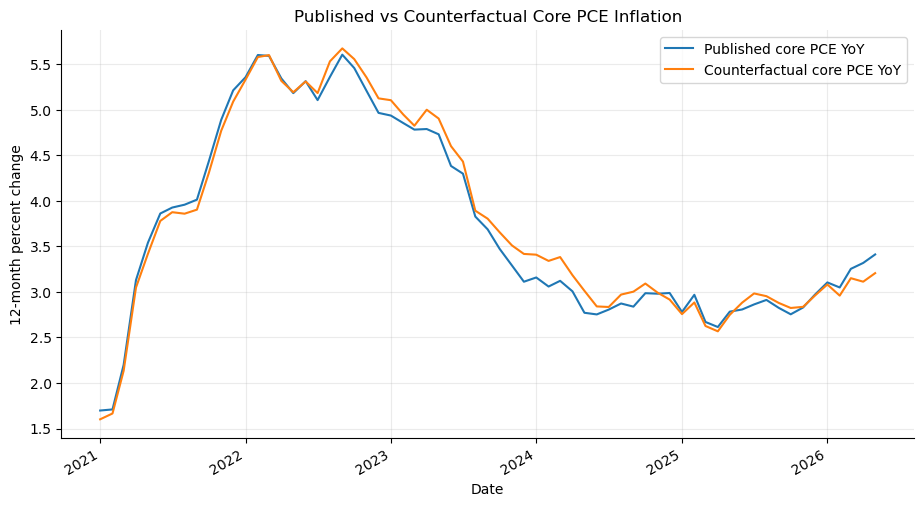

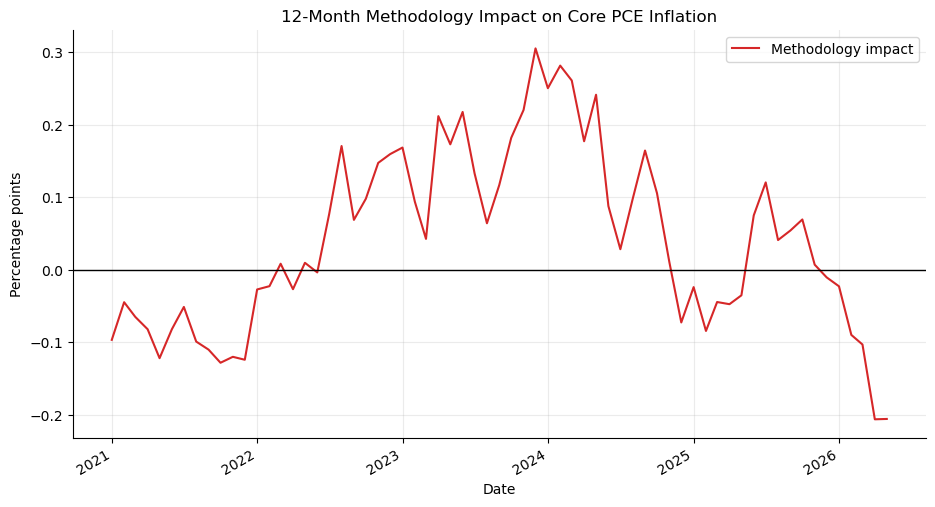

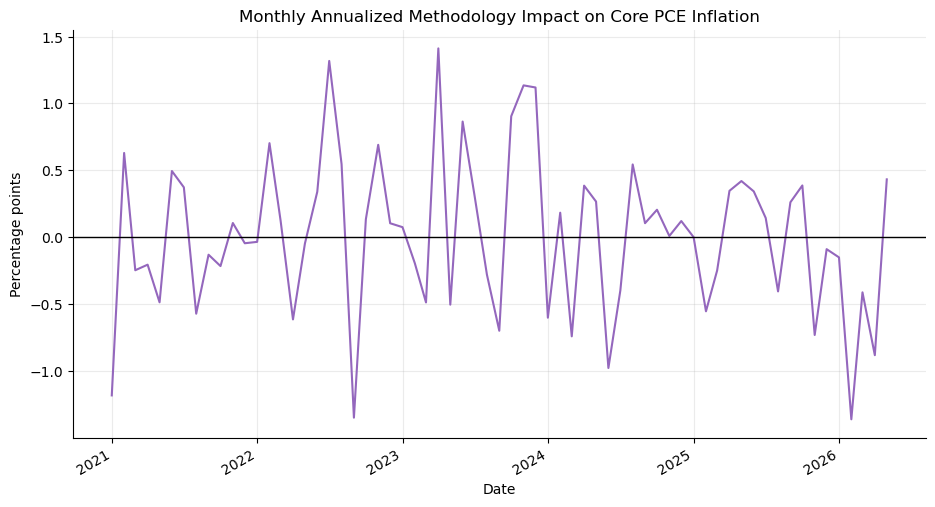

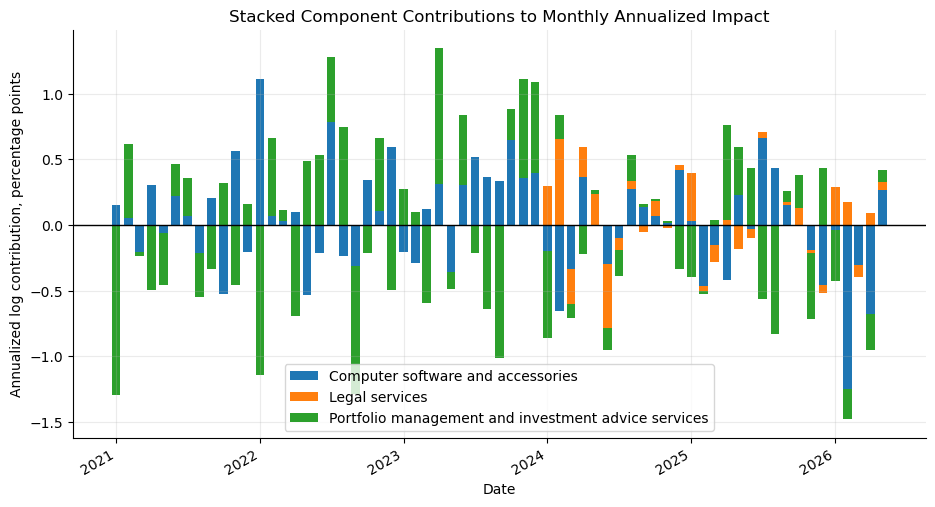

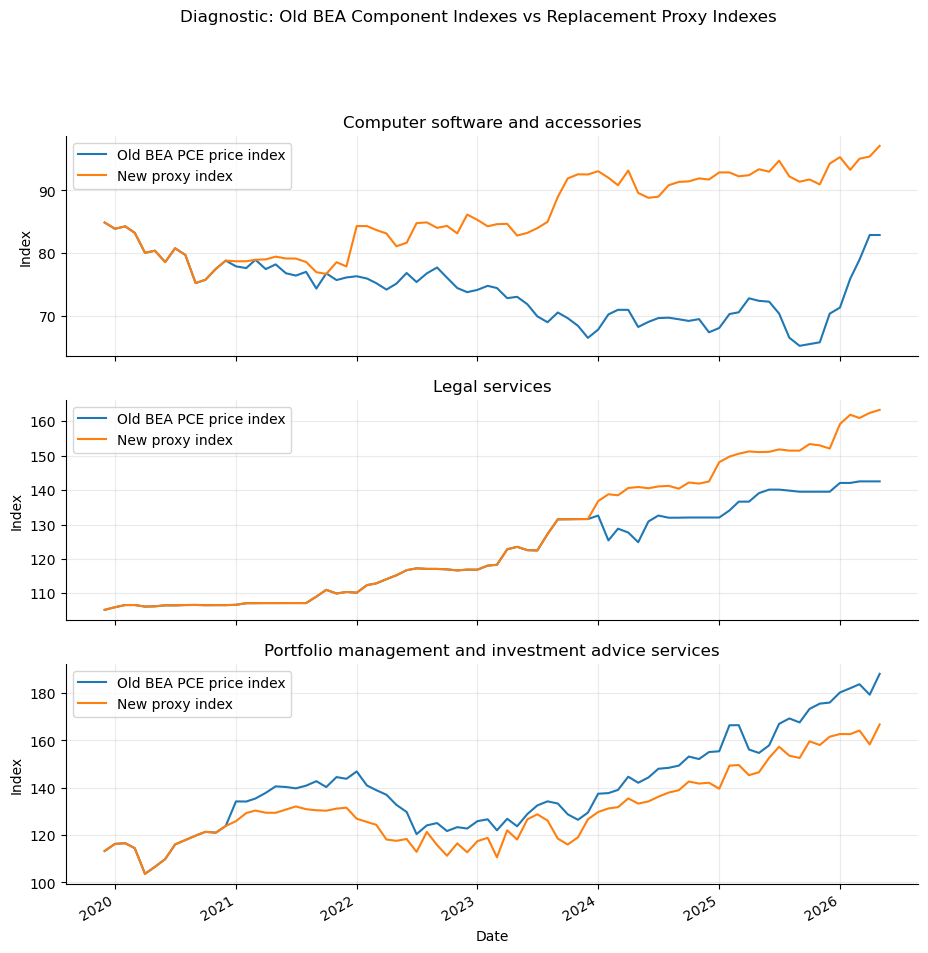

In [13]:
plot_df = core_counterfactual.dropna(subset=["core_old_yoy_pct", "core_new_yoy_pct"]).copy()

fig, ax = plt.subplots()
ax.plot(plot_df["date"], plot_df["core_old_yoy_pct"], label="Published core PCE YoY")
ax.plot(plot_df["date"], plot_df["core_new_yoy_pct"], label="Counterfactual core PCE YoY")
ax.set_title("Published vs Counterfactual Core PCE Inflation")
ax.set_ylabel("12-month percent change")
ax.set_xlabel("Date")
ax.legend()
fig.autofmt_xdate()
plt.show()


fig, ax = plt.subplots()
ax.plot(plot_df["date"], plot_df["impact_yoy_pp"], color="tab:red", label="Methodology impact")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("12-Month Methodology Impact on Core PCE Inflation")
ax.set_ylabel("Percentage points")
ax.set_xlabel("Date")
ax.legend()
fig.autofmt_xdate()
plt.show()


fig, ax = plt.subplots()
ax.plot(core_counterfactual["date"], core_counterfactual["impact_mom_ann_pp"], color="tab:purple")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Monthly Annualized Methodology Impact on Core PCE Inflation")
ax.set_ylabel("Percentage points")
ax.set_xlabel("Date")
fig.autofmt_xdate()
plt.show()


stacked = (
    component_impacts.pivot(index="date", columns="component", values="contribution_mom_ann_log_pp")
    .reindex(core_counterfactual["date"])
    .dropna(how="all")
)

fig, ax = plt.subplots()
positive_bottom = np.zeros(len(stacked))
negative_bottom = np.zeros(len(stacked))
for component in stacked.columns:
    values = stacked[component].fillna(0.0).to_numpy()
    bottoms = np.where(values >= 0, positive_bottom, negative_bottom)
    ax.bar(stacked.index, values, bottom=bottoms, width=22, label=component)
    positive_bottom += np.where(values >= 0, values, 0.0)
    negative_bottom += np.where(values < 0, values, 0.0)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Stacked Component Contributions to Monthly Annualized Impact")
ax.set_ylabel("Annualized log contribution, percentage points")
ax.set_xlabel("Date")
ax.legend(loc="best")
fig.autofmt_xdate()
plt.show()


diagnostic_indexes = {
    "Computer software and accessories": (
        component_price_indexes["Computer software and accessories"],
        new_price_indexes["Computer software and accessories"],
    ),
    "Legal services": (
        component_price_indexes["Legal services"],
        new_price_indexes["Legal services"],
    ),
    "Portfolio management and investment advice services": (
        component_price_indexes["Portfolio management and investment advice services"],
        new_price_indexes["Portfolio management and investment advice services"],
    ),
}

fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
for ax, (component, (old_idx, new_idx)) in zip(axes, diagnostic_indexes.items()):
    tmp = pd.concat({"Old BEA": old_idx, "New proxy": new_idx}, axis=1)
    tmp = tmp.loc[tmp.index >= fetch_start_date]
    ax.plot(tmp.index, tmp["Old BEA"], label="Old BEA PCE price index")
    ax.plot(tmp.index, tmp["New proxy"], label="New proxy index")
    ax.set_title(component)
    ax.set_ylabel("Index")
    ax.legend()
axes[-1].set_xlabel("Date")
fig.suptitle("Diagnostic: Old BEA Component Indexes vs Replacement Proxy Indexes", y=0.995)
fig.autofmt_xdate()
plt.show()

## 13. Diagnostics and Caveats

In [12]:
input_series = {
    "FRED PCEPILFE core PCE price index": fred["core_pce_price_index"],
    "FRED DPCCRC1M027SBEA nominal core PCE": fred["nominal_core_pce"],
    "FRED legal-services PPI": fred["ppi_legal_services"],
    "FRED portfolio-management PPI diagnostic": fred["ppi_portfolio_management"],
    "FRED game software publishing PPI": fred["ppi_game_software_publishing"],
    "FRED hosting/ASP/IT infrastructure PPI": fred["ppi_hosting_asp_it_infrastructure"],
    f"BLS CPI software raw ({cpi_software_series_id})": bls_cpi_candidates[cpi_software_series_id],
    f"BLS CPI software ({cpi_software_series_id})": bls_cpi_software,
    "Adjusted proxy source: CPI software/accessories": adjusted_proxy_sources["cpi_software_accessories"],
    "Adjusted proxy source: game software publishing PPI": adjusted_proxy_sources["ppi_game_software_publishing"],
    "Adjusted proxy source: hosting/ASP/IT infrastructure PPI": adjusted_proxy_sources["ppi_hosting_asp_it_infrastructure"],
    "Adjusted proxy source: legal-services PPI": adjusted_proxy_sources["ppi_legal_services"],
    "BLS CES portfolio quantity proxy raw": portfolio_quantity_source,
    "BLS CES portfolio quantity proxy": portfolio_quantity,
}

for component in COMPONENT_SEARCH:
    input_series[f"BEA old price index: {component}"] = component_price_indexes[component]
    input_series[f"BEA nominal PCE: {component}"] = component_nominal_harmonized[component]

input_series_diagnostics = make_diagnostics_table(
    input_series,
    start_date=fetch_start_date,
    end_date=latest_common_month,
)

display(input_series_diagnostics)

share_summary = (
    component_impacts.groupby("component")["avg_core_share"]
    .agg(["min", "median", "max"])
    .sort_values("median", ascending=False)
)
display(share_summary)

if not cpi_software_is_sa:
    print(
        "Seasonal-adjustment caveat: the main estimate uses the CPI software series as published, "
        "and the selected CPI software series is not seasonally adjusted."
    )
else:
    print("Selected CPI software series is seasonally adjusted.")

print("Optional seasonal-adjustment hook summary:")
display(seasonal_adjustment_records)

if IMPUTE_CPI_SOFTWARE_GEOMEAN_GAPS and not cpi_software_imputations.empty:
    print("CPI software imputation caveat: listed missing CPI software index levels were filled as sqrt(previous month * next month).")
    display(cpi_software_imputations)

if PORTFOLIO_QUANTITY_FLAT_NOWCAST_DATES and not portfolio_quantity_nowcast_records.empty:
    print("Portfolio quantity nowcast caveat: listed missing CES portfolio quantity levels were held flat at the previous month.")
    display(portfolio_quantity_nowcast_records)

print(
    "Caveat: Month-over-month annualized impacts can be affected by seasonal-adjustment mismatch "
    "between PCE component indexes and CPI/PPI proxy indexes. The 12-month impact is usually more "
    "reliable for this pre-release methodology estimate."
)
print(
    "Caveat: The legal-services proxy uses the aggregate legal-services PPI. The function is modular "
    "so this proxy can be replaced with a detailed legal-services PPI composite if household weights "
    "become available."
)
print(
    "Caveat: Portfolio management uses nominal PCE divided by a CES quantity proxy. The portfolio PPI "
    "is shown only as a diagnostic/reference and is not used as the new deflator."
)

# Optional placeholder for later work. This notebook intentionally does not require X-13 or any
# external seasonal-adjustment binary.
print("Seasonal-adjustment extension placeholder: add pre-adjusted proxy indexes here if available.")

,series,first_valid_date,last_valid_date,observations,missing_observations_in_window
0,BEA nominal PCE: Computer software and accesso...,1977-01-01,2026-05-01,593,0
1,BEA nominal PCE: Legal services,1959-01-01,2026-05-01,809,0
2,BEA nominal PCE: Portfolio management and inve...,1987-01-01,2026-05-01,473,0
3,BEA old price index: Computer software and acc...,1977-01-01,2026-05-01,593,0
4,BEA old price index: Legal services,1959-01-01,2026-05-01,809,0
5,BEA old price index: Portfolio management and ...,1987-01-01,2026-05-01,473,0
6,BLS CES portfolio quantity proxy,2019-01-01,2026-05-01,89,0
7,BLS CES portfolio quantity proxy raw,2019-01-01,2026-04-01,88,0
8,BLS CPI software (CUUR0000SEEE02),2019-01-01,2026-05-01,89,0
9,BLS CPI software raw (CUUR0000SEEE02),2019-01-01,2026-05-01,88,1


,min,median,max
component,,,
Portfolio management and investment advice services,0.014338,0.016575,0.019117
Computer software and accessories,0.011127,0.011959,0.012660
Legal services,0.007541,0.008086,0.008877


Seasonal-adjustment caveat: the main estimate uses the CPI software series as published, and the selected CPI software series is not seasonally adjusted.
CPI software imputation caveat: listed missing CPI software index levels were filled as sqrt(previous month * next month).


,series,date,status,previous_month,previous_value,next_month,next_value,imputed_value
0,BLS CPI software (CUUR0000SEEE02),2025-10-01,imputed as sqrt(previous * next),2025-09-01,21.991000,2025-11-01,22.182000,22.086294


Portfolio quantity nowcast caveat: listed missing CES portfolio quantity levels were held flat at the previous month.


,series,date,status,previous_month,previous_value,nowcast_value
0,BLS CES portfolio quantity proxy,2026-05-01,nowcast as previous month's value,2026-04-01,"20,815.180000","20,815.180000"


Caveat: Month-over-month annualized impacts can be affected by seasonal-adjustment mismatch between PCE component indexes and CPI/PPI proxy indexes. The 12-month impact is usually more reliable for this pre-release methodology estimate.
Caveat: The legal-services proxy uses the aggregate legal-services PPI. The function is modular so this proxy can be replaced with a detailed legal-services PPI composite if household weights become available.
Caveat: Portfolio management uses nominal PCE divided by a CES quantity proxy. The portfolio PPI is shown only as a diagnostic/reference and is not used as the new deflator.
Seasonal-adjustment extension placeholder: add pre-adjusted proxy indexes here if available.


## 14. Optional CSV Export

In [ ]:
if SAVE_OUTPUTS:
    output_dir = Path(OUTPUT_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)
    component_impacts.to_csv(output_dir / "component_methodology_impacts.csv", index=False)
    core_counterfactual.to_csv(output_dir / "core_pce_counterfactual.csv", index=False)
    input_series_diagnostics.to_csv(output_dir / "input_series_diagnostics.csv", index=False)
    component_row_matches.to_csv(output_dir / "component_row_matches.csv", index=False)
    print(f"Saved CSV outputs to {output_dir.resolve()}")
else:
    print("SAVE_OUTPUTS is False; no CSV files written.")